In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# Creating scientific figures in Python

### Goals of this workshop

**Creating histograms.** The goal of this workshop is to prepare you to create the "figures" for your final report. Matplotlib is used by a huge fraction of astronomers to create the figures for their scientific papers, and today we'll introduce one final tool for your matplotlib toolbox: the *histogram*. Histograms are very good at summarizing "distributions" in large datasets. If you perform a Monte Carlo error estimate on your data, 

**Using figures for scientific reasoning.** When you include a figure in your paper, you'll need to reference it as part of the larger story you're telling about your work. Throughout this workshop, you'll be asked to consider not just *how* to create a figure, but *what* figure to create that would be most helpful for supporting or refuting a scientific claim.

Several of the plots you make towards the end of this workshop can be used directly in your final report, if you choose to include them.

<br>

---

## 1) Comparing Ronaldo and Messi

Cristiano Ronaldo and Lionel Messi are two of the best football players (or to Americans, soccer players) of the past 50 years. Imagine you are the head of a major team, and you have the opportunity to add one of these players to your team. In this section, your goal will be to create a figure that helps you answer:

**Which player should you choose, and how do you convince others your choice is correct?**

The file "messi_ronaldo_stats.csv" contains the number of goals and assists per season for each player over an 18-year period. **Run the cell below** to load this file as a *Pandas data frame*:

In [93]:
# -- Load the Messi-Ronaldo dataset --

df_messi_ronaldo = pd.read_csv('messi_ronaldo_stats.csv')

df_messi_ronaldo

,Season,Messi Goals,Messi Assists,Ronaldo Goals,Ronaldo Assists
0,2006,8,3,12,9
1,2007,17,3,23,14
2,2008,16,13,42,8
3,2009,38,18,26,9
4,2010,47,11,33,7
5,2011,53,23,53,15
6,2012,73,29,60,15
7,2013,60,15,55,12
8,2014,41,14,51,14
9,2015,58,27,61,22


Just by looking at this table, it's not clear which player is dominant. What plot can we create that would help summarize this data?

One plot we could make is of each player's goals-per-season over time, so we can compare their season-by-season performance. Unfortunately, this plot does not make the answer clear: different players dominate during different years (see below).

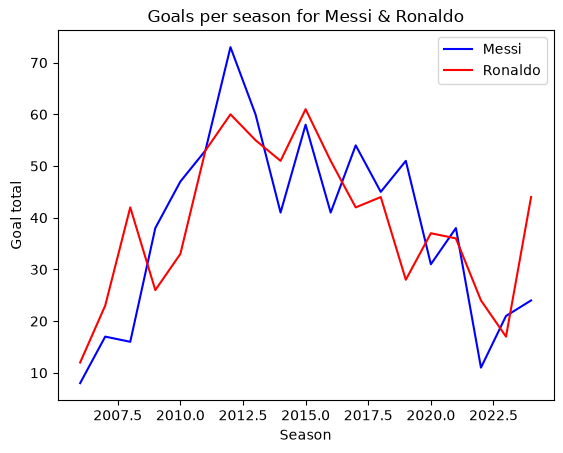

In [94]:
# -- Example: Plot "goals per season" side-by-side --

plt.title('Goals per season for Messi & Ronaldo')
plt.plot(df_messi_ronaldo['Season'], df_messi_ronaldo['Messi Goals'], color='blue', label='Messi')
plt.plot(df_messi_ronaldo['Season'], df_messi_ronaldo['Ronaldo Goals'], color='red', label='Ronaldo')
plt.legend()
plt.xlabel('Season')
plt.ylabel('Goal total')
plt.show()

### Introducing the histogram

A much more helpful type of plot here is a **histogram**. This type of plots divides up the dataset into "bins" and displays the number of values that fall within each bin.

The histogram command works as follows:
```
    plt.hist(values, bins, [STYLE ARGUMENTS])
```
* `values` should be a list/array containing the actual data
* `bins` should be a list/array specifying how you want to *bin* the data.

Each number in "bins" represents the edge of a bin. For instance, using the list
```
    bins = [5, 10, 15]
```
would give you a histogram with two bins: one from 5-10 and another from 10-15. `plt.hist` will count how many values fall in each bin and display the totals in graph form. (If a value doesn't fall in any bin, `plt.hist` simply ignores it.)

**TRY IT YOURSELF:** The cell below plots a simple histogram. Change the **bins** so that there's one value in the first bin, two in the second, and three in the third. (The bin sizes don't need to be even.)


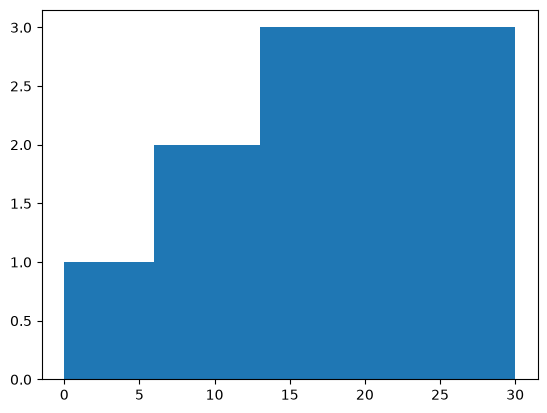

In [95]:
# -- TRY IT YOURSELF: Adjust a histogram --

values = np.array([
    5, 9, 12, 14, 17, 27
])
bins = [0, 6, 13, 30]
plt.hist(values, bins)

plt.show()

Now, we'll use `plt.hist` to make a convincing figure.

The cell below plots the goal distribution for Messi. It introduces a few techniques you'll need to know for the future:
* It creates 6 evenly-spaced bins that range from 0-80. The easiest way to do this is with **np.linspace**.
* It makes the histogram semi-transparent with **alpha=0.5**. That way, it doesn't fully cover other histograms.
* Finlly, it adds a vertical line (**plt.axvline(...)**) to mark the average goals-per-season value for each player.

**YOUR TASK:** Add the same plots for Ronaldo. Choose a unique color (orange works well) for all plot elements related to him.

* Which player comes out on top? Is the difference significant compared to the overall spread in the data? (You don't have to write this down, but make sure you have an answer!)

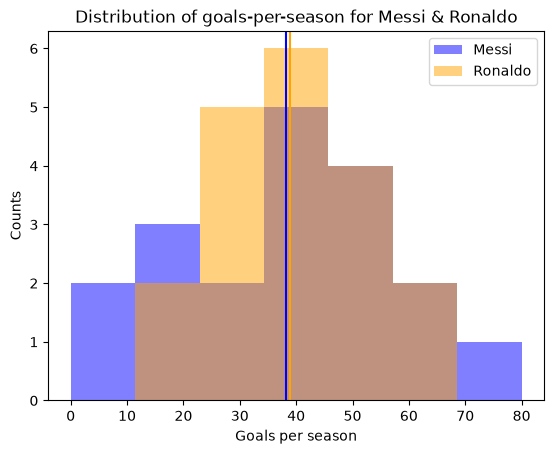

In [96]:
# -- PLOT: Goals-per-season for Messi and Ronaldo -- 

bin_count = 7
bins = np.linspace(0, 80, bin_count+1)

# Plots the goals-per-season distribution for Messi
messi_goals = df_messi_ronaldo['Messi Goals']
messi_goals_mean = np.mean(messi_goals)
plt.hist(messi_goals, bins, color='blue', alpha=0.5, label='Messi')
plt.axvline(messi_goals_mean, color='blue')

# Plots the goals-per-season distribution for Ronaldo
ronaldo_goals = df_messi_ronaldo['Ronaldo Goals']
ronaldo_goals_mean = np.mean(ronaldo_goals)
plt.hist(ronaldo_goals, bins, color='orange', alpha=0.5, label='Ronaldo')
plt.axvline(ronaldo_goals_mean, color='orange')

plt.legend()
plt.xlabel('Goals per season')
plt.ylabel('Counts')
plt.title('Distribution of goals-per-season for Messi & Ronaldo')
plt.show()

**YOUR TASK:** In the cell below, make the same plot as above, but for **assists** rather than goals. Update the bins appropriately to capture this new dataset.
* (You can start by copying & pasting the code from the cell above, but **make sure** you update all the relevant lines of code!)

**Using these two plots, is there a clear player that comes out on top?**

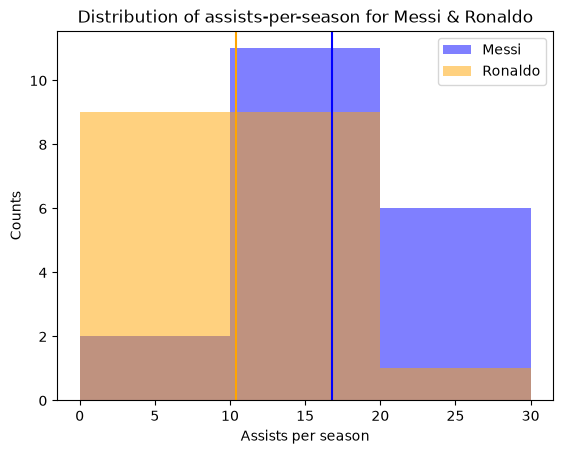

In [97]:
# -- PLOT: Assists-per-season for Messi and Ronaldo --

bin_count = 3
bins = np.linspace(0, 30, bin_count+1)

# Plots the goals-per-season distribution for Messi
messi_assists = df_messi_ronaldo['Messi Assists']
messi_assists_mean = np.mean(messi_assists)
plt.hist(messi_assists, bins, color='blue', alpha=0.5, label='Messi')
plt.axvline(messi_assists_mean, color='blue')

# Plots the goals-per-season distribution for Ronaldo
ronaldo_assists = df_messi_ronaldo['Ronaldo Assists']
ronaldo_assists_mean = np.mean(ronaldo_assists)
plt.hist(ronaldo_assists, bins, color='orange', alpha=0.5, label='Ronaldo')
plt.axvline(ronaldo_assists_mean, color='orange')

plt.legend()
plt.xlabel('Assists per season')
plt.ylabel('Counts')
plt.title('Distribution of assists-per-season for Messi & Ronaldo')
plt.show()

### Adding "selection conditions" to your data

> **"Wait!"** cries your team's coach. "Some of these seasons were a really long time ago! Does any of this change if we look only at the most recent ones?"

To answer this question, we'll need to use a **selection condition**.

Earlier in the program, you might remember using these to filter data about the Titanic:
```
    df_titanic [ df_titanic['Survived']==1 ] ['Age']
```

Here, `df_titanic['Survived']==1` is the **condition**. It selects all rows from the dataset corresponding to a survivor of the Titanic.

Selection conditions are extremely powerful, and allow you to do a lot with your data! However, they can also be cumbersome. A helpful trick is to **name** your condition `cond_NAME` before using it, like in the example below. That way, you can reuse it multiple times if needed. Here's what that looks like in practice:
```
    # Selects for all Titanic survivors
    cond_survived = (df_titanic['Survived'] == 1)

    df_titanic [cond_survived] ['Age']
```

The cell below shows another example of a selection condition, but for the Messi-Ronaldo dataset:

In [98]:
# -- EXAMPLE: Selection condition --

# Selects all seasons where Messi scored at least 50 goals
cond_messi_high_score = (df_messi_ronaldo['Messi Goals'] >= 50)

df_messi_ronaldo[cond_messi_high_score]

,Season,Messi Goals,Messi Assists,Ronaldo Goals,Ronaldo Assists
5,2011,53,23,53,15
6,2012,73,29,60,15
7,2013,60,15,55,12
9,2015,58,27,61,22
11,2017,54,16,42,12
13,2019,51,19,28,10


**YOUR TASK:** In the cell below, make the "goals-per-season" plot one last time. **This time, use only the data where 'Season' is at least 2015**. (It's best to start by copying your code from a previous cell.)

Does this affect your choice of player at all?

In [99]:
# -- PLOT: Goals-per-season for Messi and Ronaldo (since 2015) --

# Selects all seasons after 2015
cond_recent_year = (df_messi_ronaldo['Season'] >= 2015)

df_messi_ronaldo[cond_recent_year]

,Season,Messi Goals,Messi Assists,Ronaldo Goals,Ronaldo Assists
9,2015,58,27,61,22
10,2016,41,23,51,15
11,2017,54,16,42,12
12,2018,45,18,44,8
13,2019,51,19,28,10
14,2020,31,27,37,7
15,2021,38,14,36,5
16,2022,11,15,24,3
17,2023,21,20,17,2
18,2024,24,11,44,10


**With that, you have all the tools you need!** In the next section, you'll use the tools you've learned to analyze a much more complicated dataset.

<br>

---

## 2) Characterizing numbered asteroids

The dataset "jpl_numbered_asteroids.csv" contains information on **all of the numbered asteroids in JPL's database** as of January 2026. In total, this dataset has over 700,000 rows!

In a moment, we'll ask you to create some figures from this data that answer questions about your **target asteroid**. First, let's load the dataset and provide some reference information about it:

In [100]:
# -- Loads and displays the asteroid data set --

df_jpl = pd.read_csv('jpl_numbered_asteroids.csv')

df_jpl

,pdes,name,full_name,a,e,i,om,w,ma,epoch,q,per_y
0,1,Ceres,1 Ceres (A801 AA),2.766,0.0796,10.59,80.25,73.30,231.54,2461000.5,2.546,4.60
1,2,Pallas,2 Pallas (A802 FA),2.770,0.2306,34.93,172.89,310.93,211.53,2461000.5,2.131,4.61
2,3,Juno,3 Juno (A804 RA),2.671,0.2558,12.99,169.82,247.88,217.59,2461000.5,1.988,4.37
3,4,Vesta,4 Vesta (A807 FA),2.362,0.0902,7.14,103.70,151.54,26.81,2461000.5,2.149,3.63
4,5,Astraea,5 Astraea (A845 XA),2.577,0.1875,5.36,141.45,359.35,133.87,2461000.5,2.094,4.14
...,...,...,...,...,...,...,...,...,...,...,...,...
719992,719993,NaN,719993 (2023 ES4),3.166,0.0781,8.85,212.08,78.07,46.61,2461000.5,2.919,5.63
719993,719994,NaN,719994 (2023 EH5),3.140,0.0471,5.86,168.54,318.52,211.39,2461000.5,2.992,5.56
719994,719995,NaN,719995 (2023 FO15),3.216,0.1220,14.81,108.54,199.32,78.02,2461000.5,2.824,5.77
719995,719996,NaN,719996 (2023 FE23),2.611,0.2039,13.93,66.16,133.30,229.69,2461000.5,2.079,4.22


### **Column overview** 

Here are all of the columns you have available in this dataset, including their units.

* **Asteroid identifiers:**
    * `pdes`: Primary designation (an int)
    * `name` and `full_name`: More information on the asteroid's name (strings) 
* **Orbital elements:**
    * `a`: Semimajor axis (AU)
    * `e`: Eccentricity
    * `i`: Inclination (deg)
    * `om`: Longitude of the ascending node, aka "Big Omega" (deg)
    * `w`: Argument of the perihelion, aka "small omega" (deg)
    * `ma`: Mean anomaly at the "epoch" time (deg)
    * `epoch`: Time at which the asteroid had these orbital elements (Julian date)
* **Other orbital properties:**
    * `q`: Perihelion distance (AU)
    * `per_y`: Orbital period (years)

### **Asteroid groups**

There are three "asteroid groups" you'll need to know in this section. They're defined by their semimajor axis $a$ and perihelion distance $q$.

**1. Near-Earth Objects (NEOs)**:
$$
q < 1.3
$$

**2. Mars-Crossing Asteroids (MCAs)**:
$$
\begin{align}
    q &> 1.3 \\
    q &< 1.666 \\
    a &< 3.2 \\
\end{align}
$$

**3. Main Belt Asteroids (MBAs)**:
$$
\begin{align}
    q &> 1.666 \\
    a &> 2.0 \\
    a &< 3.2 \\
\end{align}
$$

**Selecting with multiple conditions:** To select some these groups from the data frame, you'll have to check for *multiple* things in your filter condition. You can do so by connecting different conditions with an `&` symbol. For instance, this condition selects for asteroids with perihelions greater than 4 AU and less than 5 AU:
```
cond_peri_4_to_5 = (df_jpl['q'] > 4) & (df_jpl['q'] < 5)
```

<br>

### **$\rightarrow$ Task 1:** How does your asteroid fit into its group?

Create a set of figures that answer the question: **Is your asteroid a typical example of an NEO or MCA?** You are welcome to use these in your final report.

**Steps:**

1. Look up your own asteroid's orbital elements in JPL Horizons. Determine whether it's a near-Earth object or a Mars-crosser by checking the condition above. (You'll need its perihelion distance; this is listed as "QR" in the horizons app.)

2. Create a condition that selects for ALL numbered NEOs or MCAs (whichever group your asteroid is in).

3. Create a histogram of the semimajor axis $a$ for all asteroids in this group (NEOs or MCAs). Add YOUR asteroid's semimajor axis on this plot with a vertical line. Give this plot a helpful title and label its axes.

4. Finally, make the same plots for eccentricity and inclination. (You'll need to choose appropriate bins for each)

**You should be able to answer the following using these figures:** Is your asteroid a typical NEO or MCA, or does its orbit stand out in some interesting way?

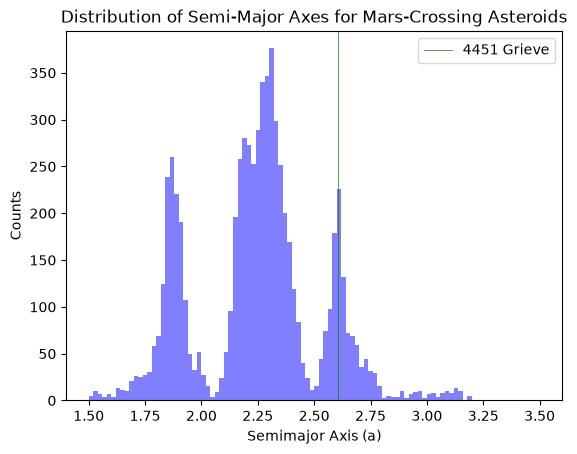

In [101]:
# -- PLOT: Putting your asteroid in context --

# YOUR CODE HERE
cond_mca = (df_jpl["q"] > 1.3) & (df_jpl["q"] < 1.666) & (df_jpl["a"] < 3.2)
df_mca = df_jpl[cond_mca]

bin_count = 100
bins = np.linspace(1.5, 3.5, bin_count+1)

plt.hist(df_mca['a'], bins, color='blue', alpha=0.5)
plt.axvline(df_mca.loc[df_mca['name'] == "Grieve", 'a'].values[0], color='green',label="4451 Grieve", linewidth=0.5)

plt.xlabel('Semimajor Axis (a)')
plt.ylabel('Counts')
plt.legend()
plt.title('Distribution of Semi-Major Axes for Mars-Crossing Asteroids')
plt.show()

### **$\rightarrow$ Task 2:** Create one or more figures that address some of the questions below

The choice is yours! Using this dataset and your tools, create a figure (or a set of figures) that answers any of the following questions. Create the cells you need below this one to write your code.

**Question 1)** A friend of yours argues that what we call the "asteroid belt" is arbitrary and made-up. Their argument: There's no clear boundary between "belt" and "not belt". There are asteroids everywhere in the solar system, and most have similar properties to those in the "belt".

> **Does it make sense to call a specific region the "asteroid belt", or is this label arbitrary and made-up?** Create one or more figures to back up your argument. (Recall: it's said that asteroids in the belt tend to have circular orbits with low inclinations.)

**Question 2)** Most asteroids have low inclination angles, but a small number have are "highly-inclined" asteroids whose orbits take them far above and below the Earth's orbital plane. Your colleague has a hypothesis that most of these asteroids got that way after drifting too close to Jupiter and being flung off course. (Jupiter orbits at roughly 5.2 AU from the Sun.)

> **Is Jupiter the source of highly-inclined asteroids (those with $i > 30^\circ$)?** Create one or more figures that support or refute this claim.

**Question 3)** A participant in a different research group is studying an asteroid whose orbit is very eccentric ($e > 0.4$). She argues as follows: "Most highly-eccentric asteroids started in the asteroid belt and were flung off course. Therefore, most of them should now *cross* the asteroid belt. They should travel closer to the Sun than 2 AU and further than 3.2 AU on each orbit."

> **Do most highly-eccentric asteroids cross the asteroid belt?** Create one or more figures that support or refute this claim.

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# Creating scientific figures in Python

### Goals of this workshop

**Creating histograms.** The goal of this workshop is to prepare you to create the "figures" for your final report. Matplotlib is used by a huge fraction of astronomers to create the figures for their scientific papers, and today we'll introduce one final tool for your matplotlib toolbox: the *histogram*. Histograms are very good at summarizing "distributions" in large datasets. If you perform a Monte Carlo error estimate on your data, 

**Using figures for scientific reasoning.** When you include a figure in your paper, you'll need to reference it as part of the larger story you're telling about your work. Throughout this workshop, you'll be asked to consider not just *how* to create a figure, but *what* figure to create that would be most helpful for supporting or refuting a scientific claim.

Several of the plots you make towards the end of this workshop can be used directly in your final report, if you choose to include them.

<br>

---

## 1) Comparing Ronaldo and Messi

Cristiano Ronaldo and Lionel Messi are two of the best football players (or to Americans, soccer players) of the past 50 years. Imagine you are the head of a major team, and you have the opportunity to add one of these players to your team. In this section, your goal will be to create a figure that helps you answer:

**Which player should you choose, and how do you convince others your choice is correct?**

The file "messi_ronaldo_stats.csv" contains the number of goals and assists per season for each player over an 18-year period. **Run the cell below** to load this file as a *Pandas data frame*:

In [103]:
# -- Load the Messi-Ronaldo dataset --

df_messi_ronaldo = pd.read_csv('messi_ronaldo_stats.csv')

df_messi_ronaldo

,Season,Messi Goals,Messi Assists,Ronaldo Goals,Ronaldo Assists
0,2006,8,3,12,9
1,2007,17,3,23,14
2,2008,16,13,42,8
3,2009,38,18,26,9
4,2010,47,11,33,7
5,2011,53,23,53,15
6,2012,73,29,60,15
7,2013,60,15,55,12
8,2014,41,14,51,14
9,2015,58,27,61,22


Just by looking at this table, it's not clear which player is dominant. What plot can we create that would help summarize this data?

One plot we could make is of each player's goals-per-season over time, so we can compare their season-by-season performance. Unfortunately, this plot does not make the answer clear: different players dominate during different years (see below).

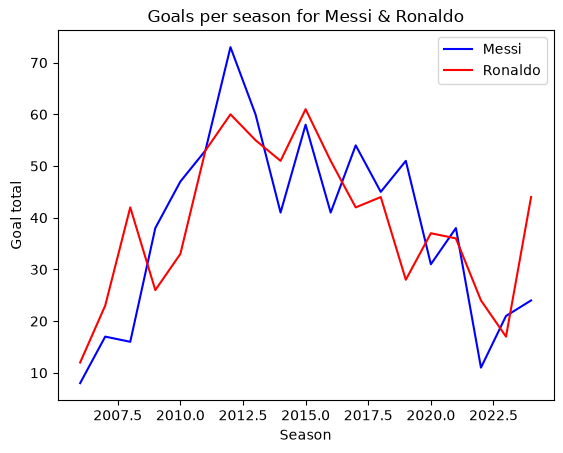

In [104]:
# -- Example: Plot "goals per season" side-by-side --

plt.title('Goals per season for Messi & Ronaldo')
plt.plot(df_messi_ronaldo['Season'], df_messi_ronaldo['Messi Goals'], color='blue', label='Messi')
plt.plot(df_messi_ronaldo['Season'], df_messi_ronaldo['Ronaldo Goals'], color='red', label='Ronaldo')
plt.legend()
plt.xlabel('Season')
plt.ylabel('Goal total')
plt.show()

### Introducing the histogram

A much more helpful type of plot here is a **histogram**. This type of plots divides up the dataset into "bins" and displays the number of values that fall within each bin.

The histogram command works as follows:
```
    plt.hist(values, bins, [STYLE ARGUMENTS])
```
* `values` should be a list/array containing the actual data
* `bins` should be a list/array specifying how you want to *bin* the data.

Each number in "bins" represents the edge of a bin. For instance, using the list
```
    bins = [5, 10, 15]
```
would give you a histogram with two bins: one from 5-10 and another from 10-15. `plt.hist` will count how many values fall in each bin and display the totals in graph form. (If a value doesn't fall in any bin, `plt.hist` simply ignores it.)

**TRY IT YOURSELF:** The cell below plots a simple histogram. Change the **bins** so that there's one value in the first bin, two in the second, and three in the third. (The bin sizes don't need to be even.)


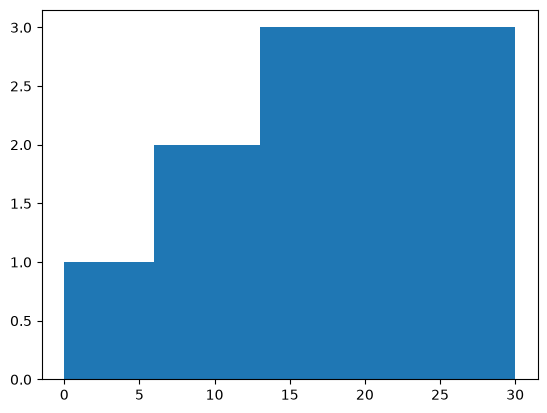

In [105]:
# -- TRY IT YOURSELF: Adjust a histogram --

values = np.array([
    5, 9, 12, 14, 17, 27
])
bins = [0, 6, 13, 30]
plt.hist(values, bins)

plt.show()

Now, we'll use `plt.hist` to make a convincing figure.

The cell below plots the goal distribution for Messi. It introduces a few techniques you'll need to know for the future:
* It creates 6 evenly-spaced bins that range from 0-80. The easiest way to do this is with **np.linspace**.
* It makes the histogram semi-transparent with **alpha=0.5**. That way, it doesn't fully cover other histograms.
* Finlly, it adds a vertical line (**plt.axvline(...)**) to mark the average goals-per-season value for each player.

**YOUR TASK:** Add the same plots for Ronaldo. Choose a unique color (orange works well) for all plot elements related to him.

* Which player comes out on top? Is the difference significant compared to the overall spread in the data? (You don't have to write this down, but make sure you have an answer!)

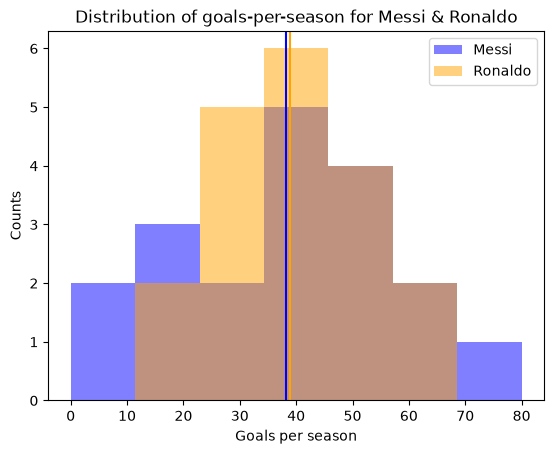

In [106]:
# -- PLOT: Goals-per-season for Messi and Ronaldo -- 

bin_count = 7
bins = np.linspace(0, 80, bin_count+1)

# Plots the goals-per-season distribution for Messi
messi_goals = df_messi_ronaldo['Messi Goals']
messi_goals_mean = np.mean(messi_goals)
plt.hist(messi_goals, bins, color='blue', alpha=0.5, label='Messi')
plt.axvline(messi_goals_mean, color='blue')

# Plots the goals-per-season distribution for Ronaldo
ronaldo_goals = df_messi_ronaldo['Ronaldo Goals']
ronaldo_goals_mean = np.mean(ronaldo_goals)
plt.hist(ronaldo_goals, bins, color='orange', alpha=0.5, label='Ronaldo')
plt.axvline(ronaldo_goals_mean, color='orange')

plt.legend()
plt.xlabel('Goals per season')
plt.ylabel('Counts')
plt.title('Distribution of goals-per-season for Messi & Ronaldo')
plt.show()

**YOUR TASK:** In the cell below, make the same plot as above, but for **assists** rather than goals. Update the bins appropriately to capture this new dataset.
* (You can start by copying & pasting the code from the cell above, but **make sure** you update all the relevant lines of code!)

**Using these two plots, is there a clear player that comes out on top?**

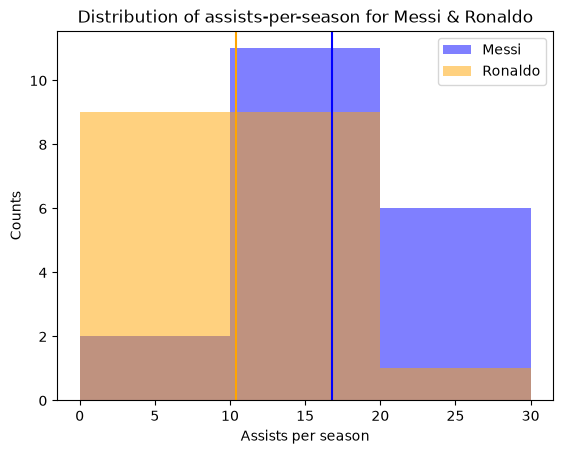

In [107]:
# -- PLOT: Assists-per-season for Messi and Ronaldo --

bin_count = 3
bins = np.linspace(0, 30, bin_count+1)

# Plots the goals-per-season distribution for Messi
messi_assists = df_messi_ronaldo['Messi Assists']
messi_assists_mean = np.mean(messi_assists)
plt.hist(messi_assists, bins, color='blue', alpha=0.5, label='Messi')
plt.axvline(messi_assists_mean, color='blue')

# Plots the goals-per-season distribution for Ronaldo
ronaldo_assists = df_messi_ronaldo['Ronaldo Assists']
ronaldo_assists_mean = np.mean(ronaldo_assists)
plt.hist(ronaldo_assists, bins, color='orange', alpha=0.5, label='Ronaldo')
plt.axvline(ronaldo_assists_mean, color='orange')

plt.legend()
plt.xlabel('Assists per season')
plt.ylabel('Counts')
plt.title('Distribution of assists-per-season for Messi & Ronaldo')
plt.show()

### Adding "selection conditions" to your data

> **"Wait!"** cries your team's coach. "Some of these seasons were a really long time ago! Does any of this change if we look only at the most recent ones?"

To answer this question, we'll need to use a **selection condition**.

Earlier in the program, you might remember using these to filter data about the Titanic:
```
    df_titanic [ df_titanic['Survived']==1 ] ['Age']
```

Here, `df_titanic['Survived']==1` is the **condition**. It selects all rows from the dataset corresponding to a survivor of the Titanic.

Selection conditions are extremely powerful, and allow you to do a lot with your data! However, they can also be cumbersome. A helpful trick is to **name** your condition `cond_NAME` before using it, like in the example below. That way, you can reuse it multiple times if needed. Here's what that looks like in practice:
```
    # Selects for all Titanic survivors
    cond_survived = (df_titanic['Survived'] == 1)

    df_titanic [cond_survived] ['Age']
```

The cell below shows another example of a selection condition, but for the Messi-Ronaldo dataset:

In [108]:
# -- EXAMPLE: Selection condition --

# Selects all seasons where Messi scored at least 50 goals
cond_messi_high_score = (df_messi_ronaldo['Messi Goals'] >= 50)

df_messi_ronaldo[cond_messi_high_score]

,Season,Messi Goals,Messi Assists,Ronaldo Goals,Ronaldo Assists
5,2011,53,23,53,15
6,2012,73,29,60,15
7,2013,60,15,55,12
9,2015,58,27,61,22
11,2017,54,16,42,12
13,2019,51,19,28,10


**YOUR TASK:** In the cell below, make the "goals-per-season" plot one last time. **This time, use only the data where 'Season' is at least 2015**. (It's best to start by copying your code from a previous cell.)

Does this affect your choice of player at all?

In [109]:
# -- PLOT: Goals-per-season for Messi and Ronaldo (since 2015) --

# Selects all seasons after 2015
cond_recent_year = (df_messi_ronaldo['Season'] >= 2015)

df_messi_ronaldo[cond_recent_year]

,Season,Messi Goals,Messi Assists,Ronaldo Goals,Ronaldo Assists
9,2015,58,27,61,22
10,2016,41,23,51,15
11,2017,54,16,42,12
12,2018,45,18,44,8
13,2019,51,19,28,10
14,2020,31,27,37,7
15,2021,38,14,36,5
16,2022,11,15,24,3
17,2023,21,20,17,2
18,2024,24,11,44,10


**With that, you have all the tools you need!** In the next section, you'll use the tools you've learned to analyze a much more complicated dataset.

<br>

---

## 2) Characterizing numbered asteroids

The dataset "jpl_numbered_asteroids.csv" contains information on **all of the numbered asteroids in JPL's database** as of January 2026. In total, this dataset has over 700,000 rows!

In a moment, we'll ask you to create some figures from this data that answer questions about your **target asteroid**. First, let's load the dataset and provide some reference information about it:

In [110]:
# -- Loads and displays the asteroid data set --

df_jpl = pd.read_csv('jpl_numbered_asteroids.csv')

df_jpl

,pdes,name,full_name,a,e,i,om,w,ma,epoch,q,per_y
0,1,Ceres,1 Ceres (A801 AA),2.766,0.0796,10.59,80.25,73.30,231.54,2461000.5,2.546,4.60
1,2,Pallas,2 Pallas (A802 FA),2.770,0.2306,34.93,172.89,310.93,211.53,2461000.5,2.131,4.61
2,3,Juno,3 Juno (A804 RA),2.671,0.2558,12.99,169.82,247.88,217.59,2461000.5,1.988,4.37
3,4,Vesta,4 Vesta (A807 FA),2.362,0.0902,7.14,103.70,151.54,26.81,2461000.5,2.149,3.63
4,5,Astraea,5 Astraea (A845 XA),2.577,0.1875,5.36,141.45,359.35,133.87,2461000.5,2.094,4.14
...,...,...,...,...,...,...,...,...,...,...,...,...
719992,719993,NaN,719993 (2023 ES4),3.166,0.0781,8.85,212.08,78.07,46.61,2461000.5,2.919,5.63
719993,719994,NaN,719994 (2023 EH5),3.140,0.0471,5.86,168.54,318.52,211.39,2461000.5,2.992,5.56
719994,719995,NaN,719995 (2023 FO15),3.216,0.1220,14.81,108.54,199.32,78.02,2461000.5,2.824,5.77
719995,719996,NaN,719996 (2023 FE23),2.611,0.2039,13.93,66.16,133.30,229.69,2461000.5,2.079,4.22


### **Column overview** 

Here are all of the columns you have available in this dataset, including their units.

* **Asteroid identifiers:**
    * `pdes`: Primary designation (an int)
    * `name` and `full_name`: More information on the asteroid's name (strings) 
* **Orbital elements:**
    * `a`: Semimajor axis (AU)
    * `e`: Eccentricity
    * `i`: Inclination (deg)
    * `om`: Longitude of the ascending node, aka "Big Omega" (deg)
    * `w`: Argument of the perihelion, aka "small omega" (deg)
    * `ma`: Mean anomaly at the "epoch" time (deg)
    * `epoch`: Time at which the asteroid had these orbital elements (Julian date)
* **Other orbital properties:**
    * `q`: Perihelion distance (AU)
    * `per_y`: Orbital period (years)

### **Asteroid groups**

There are three "asteroid groups" you'll need to know in this section. They're defined by their semimajor axis $a$ and perihelion distance $q$.

**1. Near-Earth Objects (NEOs)**:
$$
q < 1.3
$$

**2. Mars-Crossing Asteroids (MCAs)**:
$$
\begin{align}
    q &> 1.3 \\
    q &< 1.666 \\
    a &< 3.2 \\
\end{align}
$$

**3. Main Belt Asteroids (MBAs)**:
$$
\begin{align}
    q &> 1.666 \\
    a &> 2.0 \\
    a &< 3.2 \\
\end{align}
$$

**Selecting with multiple conditions:** To select some these groups from the data frame, you'll have to check for *multiple* things in your filter condition. You can do so by connecting different conditions with an `&` symbol. For instance, this condition selects for asteroids with perihelions greater than 4 AU and less than 5 AU:
```
cond_peri_4_to_5 = (df_jpl['q'] > 4) & (df_jpl['q'] < 5)
```

<br>

### **$\rightarrow$ Task 1:** How does your asteroid fit into its group?

Create a set of figures that answer the question: **Is your asteroid a typical example of an NEO or MCA?** You are welcome to use these in your final report.

**Steps:**

1. Look up your own asteroid's orbital elements in JPL Horizons. Determine whether it's a near-Earth object or a Mars-crosser by checking the condition above. (You'll need its perihelion distance; this is listed as "QR" in the horizons app.)

2. Create a condition that selects for ALL numbered NEOs or MCAs (whichever group your asteroid is in).

3. Create a histogram of the semimajor axis $a$ for all asteroids in this group (NEOs or MCAs). Add YOUR asteroid's semimajor axis on this plot with a vertical line. Give this plot a helpful title and label its axes.

4. Finally, make the same plots for eccentricity and inclination. (You'll need to choose appropriate bins for each)

**You should be able to answer the following using these figures:** Is your asteroid a typical NEO or MCA, or does its orbit stand out in some interesting way?

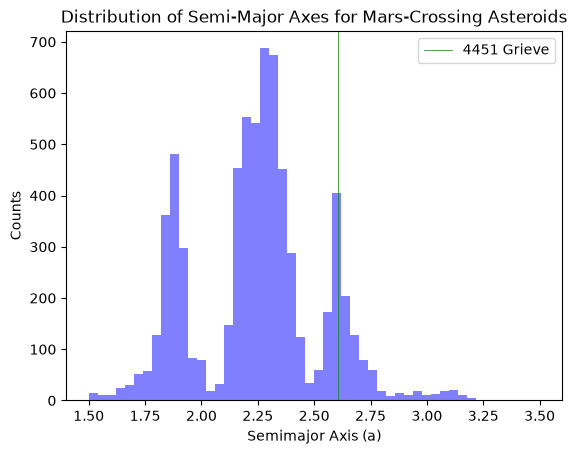

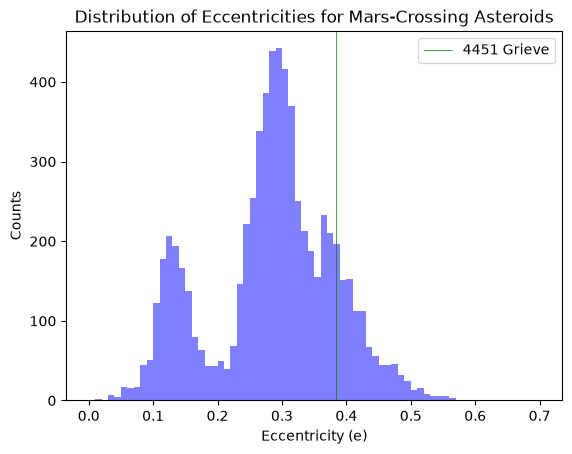

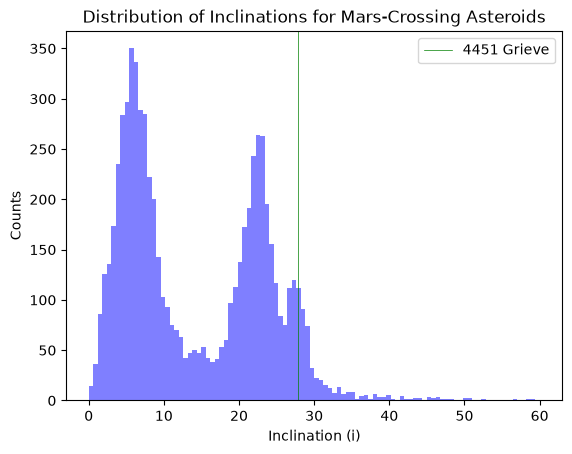

In [123]:
# -- PLOT: Putting your asteroid in context --

# YOUR CODE HERE
cond_mca = (df_jpl["q"] > 1.3) & (df_jpl["q"] < 1.666) & (df_jpl["a"] < 3.2)
df_mca = df_jpl[cond_mca]

# semimajor
bin_count = 50
bins = np.linspace(1.5, 3.5, bin_count+1)

plt.hist(df_mca['a'], bins, color='blue', alpha=0.5)
plt.axvline(df_mca.loc[df_mca['name'] == "Grieve", 'a'].values[0], color='green',label="4451 Grieve", linewidth=0.5)

plt.xlabel('Semimajor Axis (a)')
plt.ylabel('Counts')
plt.legend()
plt.title('Distribution of Semi-Major Axes for Mars-Crossing Asteroids')
plt.show()

#eccentricity
bin_count = 70
bins = np.linspace(0, 0.7, bin_count+1)

plt.hist(df_mca['e'], bins, color='blue', alpha=0.5)
plt.axvline(df_mca.loc[df_mca['name'] == "Grieve", 'e'].values[0], color='green',label="4451 Grieve", linewidth=0.5)

plt.xlabel('Eccentricity (e)')
plt.ylabel('Counts')
plt.legend()
plt.title('Distribution of Eccentricities for Mars-Crossing Asteroids')
plt.show()

#inclination
bin_count = 100
bins = np.linspace(0, 60, bin_count+1)

plt.hist(df_mca['i'], bins, color='blue', alpha=0.5)
plt.axvline(df_mca.loc[df_mca['name'] == "Grieve", 'i'].values[0], color='green',label="4451 Grieve", linewidth=0.5)

plt.xlabel('Inclination (i)')
plt.ylabel('Counts')
plt.legend()
plt.title('Distribution of Inclinations for Mars-Crossing Asteroids')
plt.show()

### **$\rightarrow$ Task 2:** Create one or more figures that address some of the questions below

The choice is yours! Using this dataset and your tools, create a figure (or a set of figures) that answers any of the following questions. Create the cells you need below this one to write your code.

**Question 1)** A friend of yours argues that what we call the "asteroid belt" is arbitrary and made-up. Their argument: There's no clear boundary between "belt" and "not belt". There are asteroids everywhere in the solar system, and most have similar properties to those in the "belt".

> **Does it make sense to call a specific region the "asteroid belt", or is this label arbitrary and made-up?** Create one or more figures to back up your argument. (Recall: it's said that asteroids in the belt tend to have circular orbits with low inclinations.)

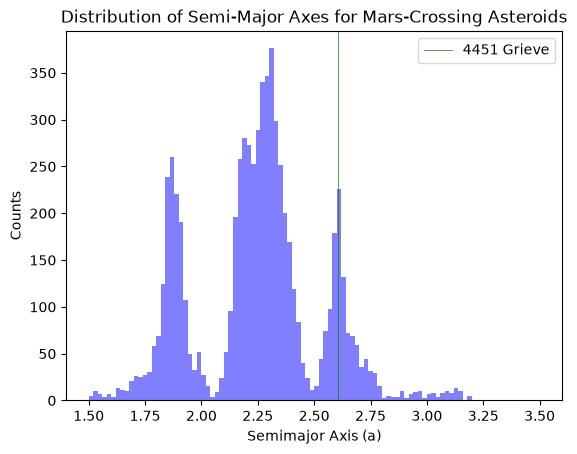

In [114]:
# -- PLOT: Answering Question 1 --

cond_mca = (df_jpl["q"] > 1.3) & (df_jpl["q"] < 1.666) & (df_jpl["a"] < 3.2)
df_mca = df_jpl[cond_mca]

bin_count = 100
bins = np.linspace(1.5, 3.5, bin_count+1)

plt.hist(df_mca['a'], bins, color='blue', alpha=0.5)
plt.axvline(df_mca.loc[df_mca['name'] == "Grieve", 'a'].values[0], color='green',label="4451 Grieve", linewidth=0.5)

plt.xlabel('Semimajor Axis (a)')
plt.ylabel('Counts')
plt.legend()
plt.title('Distribution of Semi-Major Axes for Mars-Crossing Asteroids')
plt.show()


**Question 2)** Most asteroids have low inclination angles, but a small number have are "highly-inclined" asteroids whose orbits take them far above and below the Earth's orbital plane. Your colleague has a hypothesis that most of these asteroids got that way after drifting too close to Jupiter and being flung off course. (Jupiter orbits at roughly 5.2 AU from the Sun.)

> **Is Jupiter the source of highly-inclined asteroids (those with $i > 30^\circ$)?** Create one or more figures that support or refute this claim.

**Question 3)** A participant in a different research group is studying an asteroid whose orbit is very eccentric ($e > 0.4$). She argues as follows: "Most highly-eccentric asteroids started in the asteroid belt and were flung off course. Therefore, most of them should now *cross* the asteroid belt. They should travel closer to the Sun than 2 AU and further than 3.2 AU on each orbit."

> **Do most highly-eccentric asteroids cross the asteroid belt?** Create one or more figures that support or refute this claim.